In [1]:
# -*- coding: utf-8 -*-
"""
Created on Sat Apr 27 10:57:27 2024

@author: Tomas Rampas

Sources:
https://www.statsmodels.org/dev/examples/notebooks/generated/statespace_sarimax_stata.html
https://www.statsmodels.org/dev/generated/statsmodels.tsa.statespace.sarimax.SARIMAX.html
https://www.statsmodels.org/dev/generated/statsmodels.tsa.stattools.adfuller.html
https://nixtla.github.io/statsforecast/models.html#autoarima
https://www.statsmodels.org/dev/generated/statsmodels.stats.diagnostic.acorr_ljungbox.html
"""

'\nCreated on Sat Apr 27 10:57:27 2024\n\n@author: Tomas Rampas\n\nSources:\nhttps://www.statsmodels.org/dev/examples/notebooks/generated/statespace_sarimax_stata.html\nhttps://www.statsmodels.org/dev/generated/statsmodels.tsa.statespace.sarimax.SARIMAX.html\nhttps://www.statsmodels.org/dev/generated/statsmodels.tsa.stattools.adfuller.html\nhttps://nixtla.github.io/statsforecast/models.html#autoarima\nhttps://www.statsmodels.org/dev/generated/statsmodels.stats.diagnostic.acorr_ljungbox.html\n'

## Time Series Analysis Models for S&P 500 (^GSPC) using StatsForecast

This notebook performs time series analysis on S&P 500 daily closing prices.
We will:
1. Load and preprocess the data (calculate log returns).
2. Check for stationarity using the Augmented Dickey-Fuller (ADF) test.
3. Visualize Autocorrelation (ACF) and Partial Autocorrelation (PACF) plots.
4. Explain how to interpret ACF/PACF for manual model selection.
5. Fit an ARIMA model automatically using `statsforecast.models.AutoARIMA`.
6. Perform residual diagnostics on the chosen model.
7. Generate forecasts and discuss their limitations.

### 1. Load Data and Preprocessing

[*********************100%***********************]  1 of 1 completed


--- Original Data ---
Price         Adj Close        Close         High          Low         Open  \
Ticker            ^GSPC        ^GSPC        ^GSPC        ^GSPC        ^GSPC   
Date                                                                          
2010-01-04  1132.989990  1132.989990  1133.869995  1116.560059  1116.560059   
2010-01-05  1136.520020  1136.520020  1136.630005  1129.660034  1132.660034   
2010-01-06  1137.140015  1137.140015  1139.189941  1133.949951  1135.709961   
2010-01-07  1141.689941  1141.689941  1142.459961  1131.319946  1136.270020   
2010-01-08  1144.979980  1144.979980  1145.390015  1136.219971  1140.520020   

Price           Volume  
Ticker           ^GSPC  
Date                    
2010-01-04  3991400000  
2010-01-05  2491020000  
2010-01-06  4972660000  
2010-01-07  5270680000  
2010-01-08  4389590000  


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3522 entries, 2010-01-04 to 2023-12-29
Data columns (total 6 columns):
 #   Column        

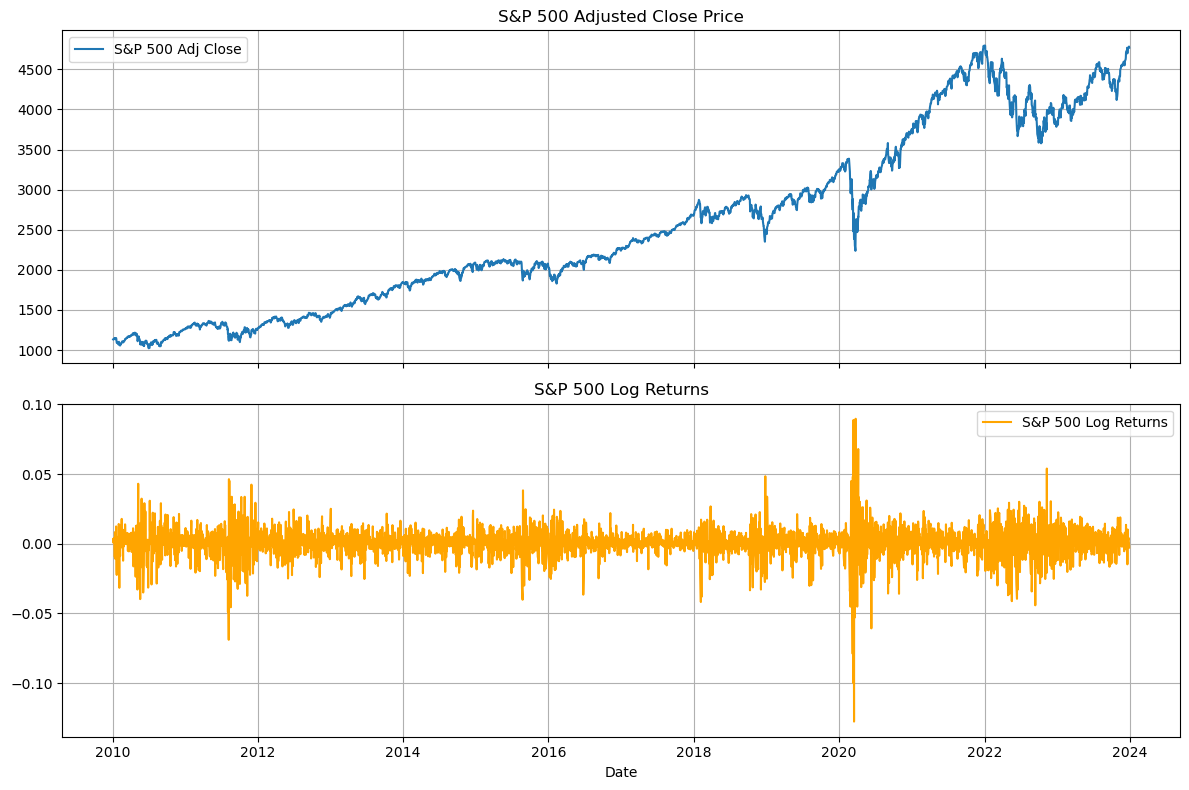


--- Log Returns Series ---
Date
2010-01-05    0.003111
2010-01-06    0.000545
2010-01-07    0.003993
2010-01-08    0.002878
2010-01-11    0.001745
Name: log_returns, dtype: float64


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

# StatsForecast imports
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA
from statsforecast.arima import arima_string

# Statsmodels imports for diagnostics
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox # For Ljung-Box test

# Suppress specific warnings if needed (optional)
warnings.filterwarnings('ignore', category=FutureWarning) # Example

# Define the ticker symbol and date range
ticker = '^GSPC' # S&P 500
start_date = '2010-01-01'
end_date = '2023-12-31' # Use a more recent end date if desired

# Download the data
df_raw = yf.download(ticker, start=start_date, end=end_date, auto_adjust=False)

# Display the first few rows and info
print("--- Original Data ---")
print(df_raw.head())
print("\n")
print(df_raw.info())

# Use Adjusted Close prices
df_close = df_raw[['Adj Close']].copy()

# Calculate Log Returns (often more stationary than prices)
df_close['log_returns'] = np.log(df_close['Adj Close'] / df_close['Adj Close'].shift(1))

# Remove the first NaN value resulting from the shift
log_returns_series = df_close['log_returns'].dropna()

# Plot Adjusted Close prices and Log Returns
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(df_close['Adj Close'], label='S&P 500 Adj Close')
axes[0].set_title('S&P 500 Adjusted Close Price')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(log_returns_series, label='S&P 500 Log Returns', color='orange')
axes[1].set_title('S&P 500 Log Returns')
axes[1].legend()
axes[1].grid(True)

plt.xlabel('Date')
plt.tight_layout()
plt.show()

print("\n--- Log Returns Series ---")
print(log_returns_series.head())

### 2. Stationarity Check (ADF Test)

We use the Augmented Dickey-Fuller (ADF) test to check if the log returns series is stationary.

* **Null Hypothesis (H0):** The series has a unit root (is non-stationary).
* **Alternative Hypothesis (H1):** The series does not have a unit root (is stationary).

We reject H0 if the p-value is less than a significance level (e.g., 0.05). The result helps decide if differencing (`d` parameter in ARIMA) is needed, although `AutoARIMA` can often determine this automatically.

In [3]:
# Perform ADF test on log returns
print("\n--- ADF Test on Log Returns ---")
adf_test = adfuller(log_returns_series, autolag='AIC')

# Extract and print results
adf_statistic = adf_test[0]
p_value = adf_test[1]
critical_values = adf_test[4]

print(f'ADF Statistic: {adf_statistic:.4f}')
print(f'p-value: {p_value:.4f}')
print('Critical Values:')
for key, value in critical_values.items():
    print(f'   {key}: {value:.4f}')

# Interpretation
alpha = 0.05
if p_value <= alpha:
    print(f"\nConclusion (alpha={alpha}): Reject the null hypothesis (H0).")
    print("The log returns series is likely stationary.")
    # AutoARIMA can determine d, but we note d=0 is likely appropriate.
else:
    print(f"\nConclusion (alpha={alpha}): Fail to reject the null hypothesis (H0).")
    print("The log returns series is likely non-stationary.")
    # AutoARIMA should handle differencing if needed.



--- ADF Test on Log Returns ---
ADF Statistic: -12.9088
p-value: 0.0000
Critical Values:
   1%: -3.4322
   5%: -2.8624
   10%: -2.5672

Conclusion (alpha=0.05): Reject the null hypothesis (H0).
The log returns series is likely stationary.


### 3. ACF and PACF Plots

We plot the Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) for the (likely stationary) log returns series. These plots can provide hints about the AR (`p`) and MA (`q`) orders, although `AutoARIMA` will determine these automatically.


--- ACF and PACF Plots for Log Returns ---


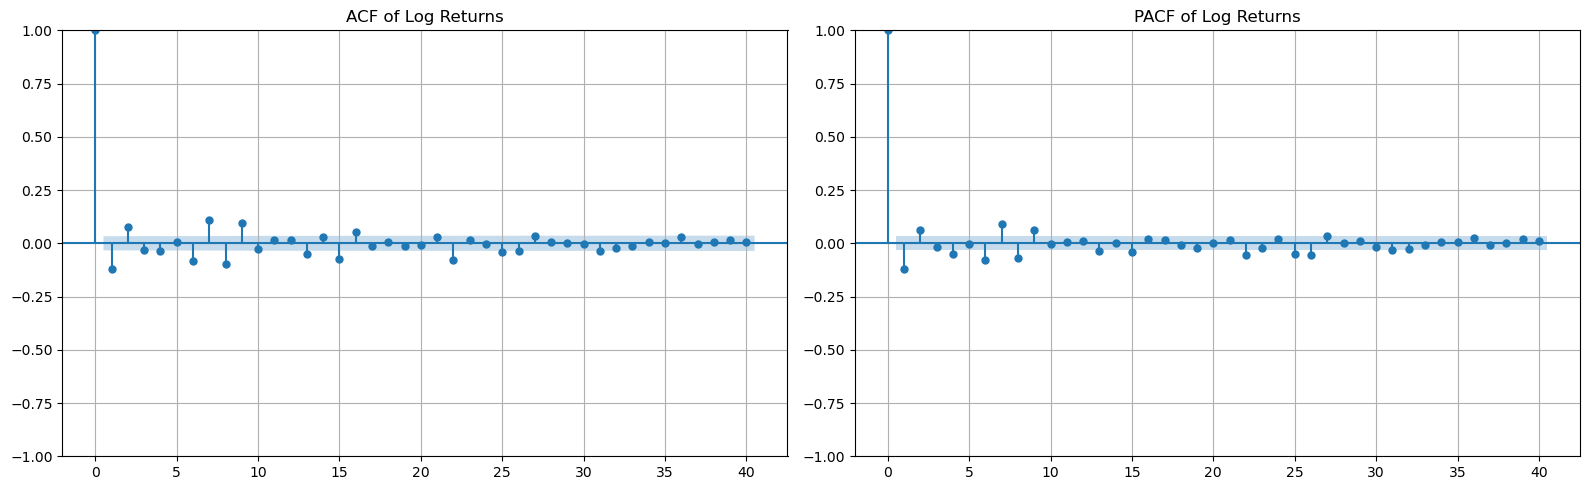

In [4]:
print("\n--- ACF and PACF Plots for Log Returns ---")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot ACF
plot_acf(log_returns_series, lags=40, ax=axes[0], title='ACF of Log Returns')
axes[0].grid(True)

# Plot PACF
plot_pacf(log_returns_series, lags=40, ax=axes[1], title='PACF of Log Returns')
axes[1].grid(True)

plt.tight_layout()
plt.show()

### 4. Interpreting ACF and PACF Plots (for Log Returns)

We examine the ACF and PACF plots of the log returns series:

* **PACF:** Look for a sharp cut-off after lag `p` to suggest AR order.
* **ACF:** Look for a sharp cut-off after lag `q` to suggest MA order.
* **Decaying Patterns:** If both decay, an ARMA(p,q) model might be needed.

**Typical Observation for Financial Log Returns:** Often, few significant spikes are seen, suggesting simpler models are appropriate. This reinforces the utility of automated model selection.

### 5. Prepare Data and Fit AutoARIMA with StatsForecast

`StatsForecast` requires data in a specific format: a pandas DataFrame with columns `unique_id`, `ds` (datetime), and `y` (target value).

In [5]:
# Prepare DataFrame for StatsForecast
df_sf = log_returns_series.reset_index()
df_sf.rename(columns={'Date': 'ds', 'log_returns': 'y'}, inplace=True)
df_sf['unique_id'] = 'GSPC' # Add the required unique_id column

print("--- Data Prepared for StatsForecast ---")
print(df_sf.head())

# Define the model
# AutoARIMA from statsforecast will automatically select p, d, q
# We specify the frequency 'B' for Business days
sf = StatsForecast(
    models=[AutoARIMA()],
    freq='B'
)

# Fit the model
print("\n--- Fitting AutoARIMA with StatsForecast ---")
sf.fit(df_sf)
print("Fitting complete.")

arima_string(sf.fitted_[0,0].model_)
# Note: Accessing the exact chosen (p,d,q) order might require inspecting internal attributes 
# or fitting verbosely, which is not straightforwardly exposed in the main API after fitting.
# We will proceed without the exact order for diagnostics adjustment for now.

--- Data Prepared for StatsForecast ---
          ds         y unique_id
0 2010-01-05  0.003111      GSPC
1 2010-01-06  0.000545      GSPC
2 2010-01-07  0.003993      GSPC
3 2010-01-08  0.002878      GSPC
4 2010-01-11  0.001745      GSPC

--- Fitting AutoARIMA with StatsForecast ---
Fitting complete.


'ARIMA(2,0,2) with non-zero mean'

### 6. Residual Diagnostics

We check if the model residuals behave like white noise. We obtain in-sample forecasts to calculate residuals.

**Ljung-Box Test:**
* **H0:** Residuals are independently distributed (white noise).
* **H1:** Residuals are not independently distributed.

Fail to reject H0 if p-values > 0.05.


--- Residual Diagnostics for Auto ARIMA Model ---
predict_in_sample not found, using predict with appropriate h value.


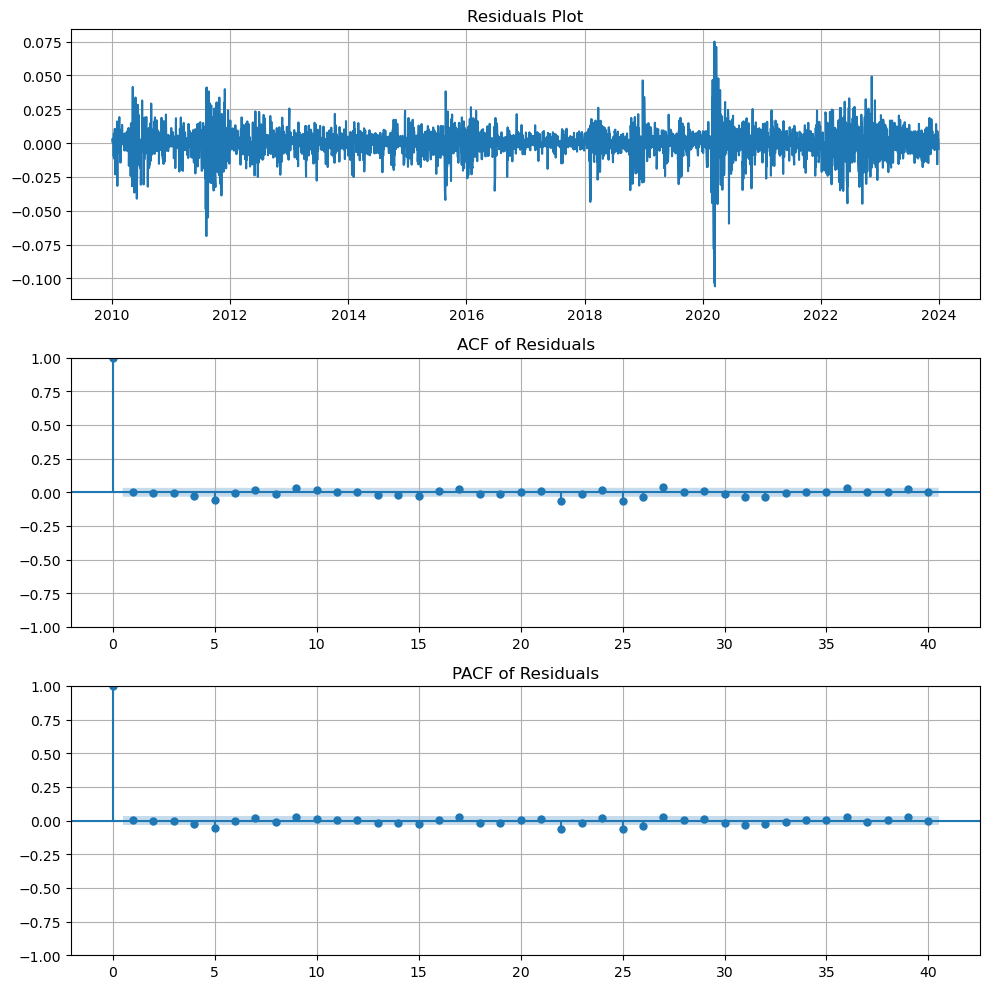


Ljung-Box Test on Residuals:
      lb_stat  lb_pvalue
1    0.044744   0.832475
2    0.184012   0.912100
3    0.191474   0.978954
4    2.759619   0.598823
5   13.936079   0.016021
6   13.947921   0.030223
7   15.417491   0.031005
8   15.843726   0.044672
9   19.042600   0.024833
10  20.142289   0.027935
11  20.180336   0.042928
12  20.184207   0.063681
13  21.420198   0.065023
14  23.258618   0.056190
15  25.802083   0.040155
16  26.039859   0.053470
17  28.544985   0.038959
18  29.268722   0.045192
19  29.904705   0.053024
20  29.970370   0.070335
21  30.364548   0.084904
22  43.904712   0.003645
23  44.485572   0.004593
24  45.868514   0.004591
25  60.283962   0.000096
26  64.534649   0.000040
27  69.199983   0.000015
28  69.237480   0.000024
29  69.597427   0.000034
30  69.978504   0.000049
31  73.798310   0.000024
32  77.415278   0.000012
33  77.555394   0.000019
34  77.630708   0.000029
35  77.744121   0.000044
36  81.488020   0.000022
37  81.488194   0.000034
38  81.549220   0.00

In [14]:
print("\n--- Residual Diagnostics for Auto ARIMA Model ---")

# Get in-sample forecasts to calculate residuals
# Note: predict asks for future predictions, use predict_in_sample for residuals
try:
    # Use predict_in_sample if available (newer versions)
    result=sf.fitted_[0,0].model_
    in_sample_fcst = result.predict_in_sample()    
except AttributeError:
    # Fallback for older versions: Predict on the training data
    print("predict_in_sample not found, using predict with appropriate h value.")
    # Predict with a numerical value for h, not the DataFrame itself
    in_sample_fcst = sf.predict(h=5) # Just predict one step ahead for demonstration

# Merge actuals and forecasts
# Ensure alignment on 'ds' and 'unique_id'
results_df = pd.merge(df_sf, in_sample_fcst, on=['unique_id', 'ds'], how='left')

# Calculate residuals
#results_df['residuals'] = results_df['y'] - results_df['AutoARIMA']
results_df['residuals'] = pd.DataFrame(result.get("residuals"), columns=["residual Model"])
residuals = results_df['residuals'].dropna().reset_index(drop=True)

if residuals.empty:
    print("Error: Could not calculate residuals. Check forecast alignment.")
else:
    # Plot residuals and their ACF/PACF
    fig, axes = plt.subplots(3, 1, figsize=(10, 10))

    axes[0].plot(results_df['ds'], results_df['residuals'])
    axes[0].set_title('Residuals Plot')
    axes[0].grid(True)

    plot_acf(residuals, lags=40, ax=axes[1], title='ACF of Residuals')
    axes[1].grid(True)

    plot_pacf(residuals, lags=40, ax=axes[2], title='PACF of Residuals')
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

    # Perform Ljung-Box test on residuals
    n_lags = min(40, len(residuals)//5)
    # Note: We cannot easily get the exact (p,q) order from statsforecast's AutoARIMA 
    # after fitting to adjust degrees of freedom (model_df). 
    # We perform the test without this adjustment, which might slightly affect p-values.
    lb_test = acorr_ljungbox(residuals, lags=n_lags, return_df=True)

    print("\nLjung-Box Test on Residuals:")
    print(lb_test)

    alpha_lb = 0.05
    if (lb_test['lb_pvalue'] <= alpha_lb).any():
         print(f"\nWarning: Ljung-Box test indicates residuals may NOT be white noise (at least one p-value <= {alpha_lb}).")
         print("The model might not fully capture the autocorrelation structure.")
    else:
         print(f"\nLjung-Box test suggests residuals resemble white noise (all p-values > {alpha_lb}).")
         print("The model appears adequate based on this test (ignoring df adjustment).")

### 7. Forecasting

We use the fitted `StatsForecast` object to forecast the next few periods (e.g., 30 business days) of log returns.

**Important Note:** Forecasting financial returns is extremely difficult. These forecasts primarily reflect statistical properties and should **not** be treated as reliable predictions of future market movements. Confidence intervals show the high uncertainty.


--- Forecasting Next 30 Periods ---
   unique_id         ds  AutoARIMA  AutoARIMA-lo-95  AutoARIMA-hi-95
0       GSPC 2024-01-01  -0.000437        -0.021710         0.020836
1       GSPC 2024-01-02   0.001432        -0.019939         0.022802
2       GSPC 2024-01-03  -0.000615        -0.022029         0.020799
3       GSPC 2024-01-04   0.001275        -0.020146         0.022697
4       GSPC 2024-01-05  -0.000192        -0.021615         0.021230
5       GSPC 2024-01-08   0.000686        -0.020753         0.022125
6       GSPC 2024-01-09   0.000452        -0.021024         0.021929
7       GSPC 2024-01-10   0.000092        -0.021433         0.021617
8       GSPC 2024-01-11   0.000913        -0.020656         0.022482
9       GSPC 2024-01-12  -0.000183        -0.021782         0.021415
10      GSPC 2024-01-15   0.000985        -0.020625         0.022595
11      GSPC 2024-01-16  -0.000069        -0.021680         0.021543
12      GSPC 2024-01-17   0.000726        -0.020887         0.0223

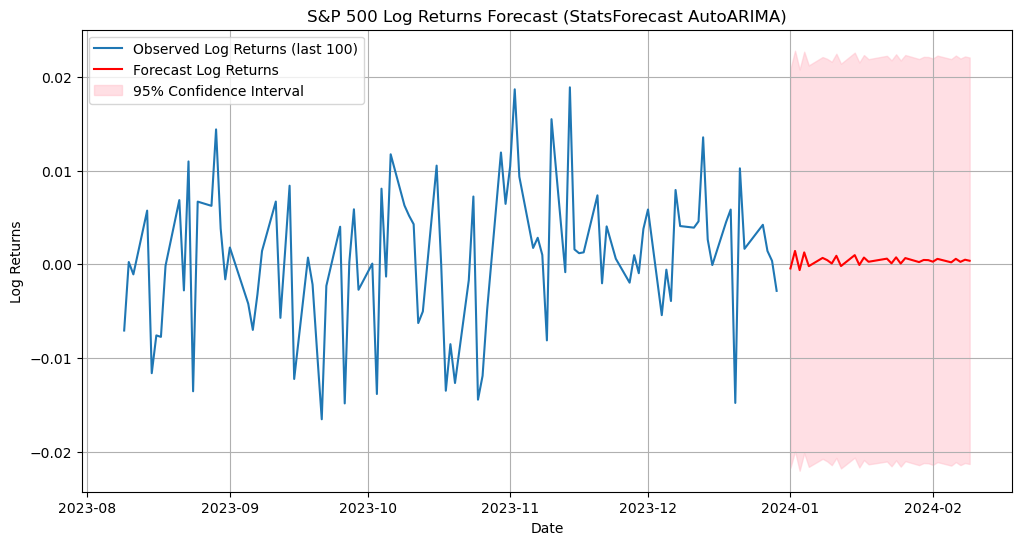

In [15]:
# Forecast future values
n_periods = 30 # Number of periods (business days) to forecast

print(f"\n--- Forecasting Next {n_periods} Periods ---")
# The predict method requires the forecast horizon 'h'
# It automatically generates future 'ds' based on the frequency ('B')
forecast_df = sf.predict(h=n_periods, level=[95]) # level=[95] requests 95% CI

# Display forecast results
print(forecast_df)

# Plot the forecast
plt.figure(figsize=(12, 6))
# Plot recent history (using the original series for context)
plt.plot(log_returns_series.tail(100), label='Observed Log Returns (last 100)') 

# Plot forecast values
plt.plot(forecast_df['ds'], forecast_df['AutoARIMA'], label='Forecast Log Returns', color='red')

# Plot confidence intervals
plt.fill_between(forecast_df['ds'],
                 forecast_df['AutoARIMA-lo-95'],
                 forecast_df['AutoARIMA-hi-95'],
                 color='pink', alpha=0.5, label='95% Confidence Interval')

plt.title(f'S&P 500 Log Returns Forecast (StatsForecast AutoARIMA)')
plt.xlabel('Date')
plt.ylabel('Log Returns')
plt.legend()
plt.grid(True)
plt.show()

### Conclusion

This notebook demonstrated a time series analysis workflow using `statsforecast`:
- Data loading and preprocessing.
- Stationarity testing (ADF).
- Visualizing ACF/PACF.
- Preparing data for `statsforecast`.
- Using `AutoARIMA` for automatic model selection and fitting.
- Performing residual diagnostics (plots, Ljung-Box test).
- Generating forecasts and emphasizing their limitations.

`statsforecast` provides a scalable alternative for fitting time series models. Further analysis could explore other models within the library or GARCH models for volatility.